In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Data_sets/used_cars.csv", na_values=['', 'NaN', 'nan','NULL','null','N/A', 'n/a', 'None', 'not supported'])

### Basic EDA

In [4]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3837 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [6]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [7]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       172
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

### Handling NULL values

In [9]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Values" : missing_values,
    "Missing Percentage" : missing_percent
})

missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)
print(missing_df)

             Missing Values  Missing Percentage
clean_title             596           14.866550
fuel_type               172            4.290347
accident                113            2.818658


In [10]:
clean_df = df.copy()

In [13]:
numerical_cols = clean_df.select_dtypes(include=np.number).columns.to_list()
categorical_cols = clean_df.select_dtypes(include=["object"]).columns.to_list()

C:\Users\HP\AppData\Local\Temp\ipykernel_8440\3670547067.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = clean_df.select_dtypes(include=["object"]).columns.to_list()


In [14]:
numerical_cols

['model_year']

In [15]:
categorical_cols

['brand',
 'model',
 'milage',
 'fuel_type',
 'engine',
 'transmission',
 'ext_col',
 'int_col',
 'accident',
 'clean_title',
 'price']

In [ ]:
for col in numerical_cols:
    if clean_df[col].isnull().sum() > 0:
        median_value = clean_df[col].median()
        clean_df[col].fillna(median_value,inplace=True)

In [17]:
for col in categorical_cols:
    missing_count = clean_df[col].isnull().sum()
    if missing_count > 0:
        # Get mode, excluding NaN values
        mode_list = clean_df[col].dropna().mode()
        if len(mode_list) > 0:
            mode_value = mode_list[0]
            clean_df[col] = clean_df[col].fillna(mode_value)
            print(f"Filled {col}: {missing_count} missing values with '{mode_value}'")
        else:
            # If all values are NaN, fill with a placeholder
            clean_df[col] = clean_df[col].fillna("missing")
            print(f"Filled {col}: {missing_count} missing values with 'missing'")

Filled fuel_type: 172 missing values with 'Gasoline'
Filled accident: 113 missing values with 'None reported'
Filled clean_title: 596 missing values with 'Yes'


In [18]:
clean_df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [19]:
df.head(2)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"


In [20]:
df.dtypes

brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

### Basic feature engineering and changing datatypes

In [21]:
clean_df['price'] = clean_df['price'].str.replace("$", "").str.replace(",","").astype('Float64')

In [22]:
clean_df['price'].head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: Float64

In [27]:
clean_df['milage'].astype('Float64')

0       51000.0
1       34742.0
2       22372.0
3       88900.0
4        9835.0
         ...   
4004      714.0
4005    10900.0
4006     2116.0
4007    33000.0
4008    43000.0
Name: milage, Length: 4009, dtype: Float64

In [28]:
import re

# Extract horsepower
clean_df['horsepower'] = clean_df['engine'].str.extract(r'(\d+\.?\d*)(?:\.0)?HP', expand=False).astype('Float64')

# Extract liters (handles both "3.7L" and "3.5 Liter" formats)
clean_df['liters'] = clean_df['engine'].str.extract(r'(\d+\.?\d*)\s*L(?:iter)?', expand=False).astype('Float64')

In [29]:
clean_df.head(2)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,horsepower,liters
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,300.0,3.7
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,<NA>,3.8


In [30]:
clean_df[["horsepower", "liters"]].isnull().sum()

horsepower    808
liters        217
dtype: int64

In [32]:
new_columns = clean_df[['horsepower', 'liters']].columns.tolist()
new_columns

['horsepower', 'liters']

In [39]:
for col in new_columns:
    if clean_df[col].isnull().sum() > 0:
        median_value = clean_df[col].median() 
        clean_df[col].fillna(median_value, inplace=True)

# Verify the fill worked
print(clean_df[['horsepower', 'liters']].isnull().sum())

horsepower    808
liters        217
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_8440\381296170.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  clean_df[col].fillna(median_value, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_8440\381296170.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an 

In [40]:
clean_df['horsepower'] = clean_df['horsepower'].fillna(0)


In [41]:
median_liters = clean_df['liters'].median()

if pd.isna(median_liters):
    clean_df['liters'] = clean_df['liters'].fillna(0)  # Use 0 as default
else:
    clean_df['liters'] = clean_df['liters'].fillna(median_liters)

In [42]:
clean_df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,horsepower,liters
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,300.0,3.7
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,0.0,3.8
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Yes,54598.0,0.0,3.5
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,354.0,3.5
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,34999.0,0.0,2.0


In [43]:
clean_df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
horsepower      0
liters          0
dtype: int64

In [38]:
clean_df.shape

(4009, 14)

In [44]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   str    
 1   model         4009 non-null   str    
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   Int64  
 4   fuel_type     4009 non-null   str    
 5   engine        4009 non-null   str    
 6   transmission  4009 non-null   str    
 7   ext_col       4009 non-null   str    
 8   int_col       4009 non-null   str    
 9   accident      4009 non-null   str    
 10  clean_title   4009 non-null   str    
 11  price         4009 non-null   Float64
 12  horsepower    4009 non-null   Float64
 13  liters        4009 non-null   Float64
dtypes: Float64(3), Int64(1), int64(1), str(9)
memory usage: 454.3 KB


In [45]:
clean_df = clean_df.drop('engine', axis=1)

In [48]:
clean_df['is_accident'] = clean_df['accident'].apply(lambda x:"NO" if x == "None reported" else "YES")

In [49]:
clean_df.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,horsepower,liters,is_accident
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,300.0,3.7,YES
1,Hyundai,Palisade SEL,2021,34742,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,0.0,3.8,YES
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Automatic,Blue,Black,None reported,Yes,54598.0,0.0,3.5,NO
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500.0,354.0,3.5,NO
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,34999.0,0.0,2.0,NO


In [50]:
clean_df = clean_df.drop('accident', axis=1)

In [51]:
clean_df.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,clean_title,price,horsepower,liters,is_accident
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,Yes,10300.0,300.0,3.7,YES
1,Hyundai,Palisade SEL,2021,34742,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,0.0,3.8,YES
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Automatic,Blue,Black,Yes,54598.0,0.0,3.5,NO
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,354.0,3.5,NO
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,Yes,34999.0,0.0,2.0,NO


### Duplicate detection and removal

In [52]:
clean_df.duplicated().sum()

np.int64(0)

### Visualizations

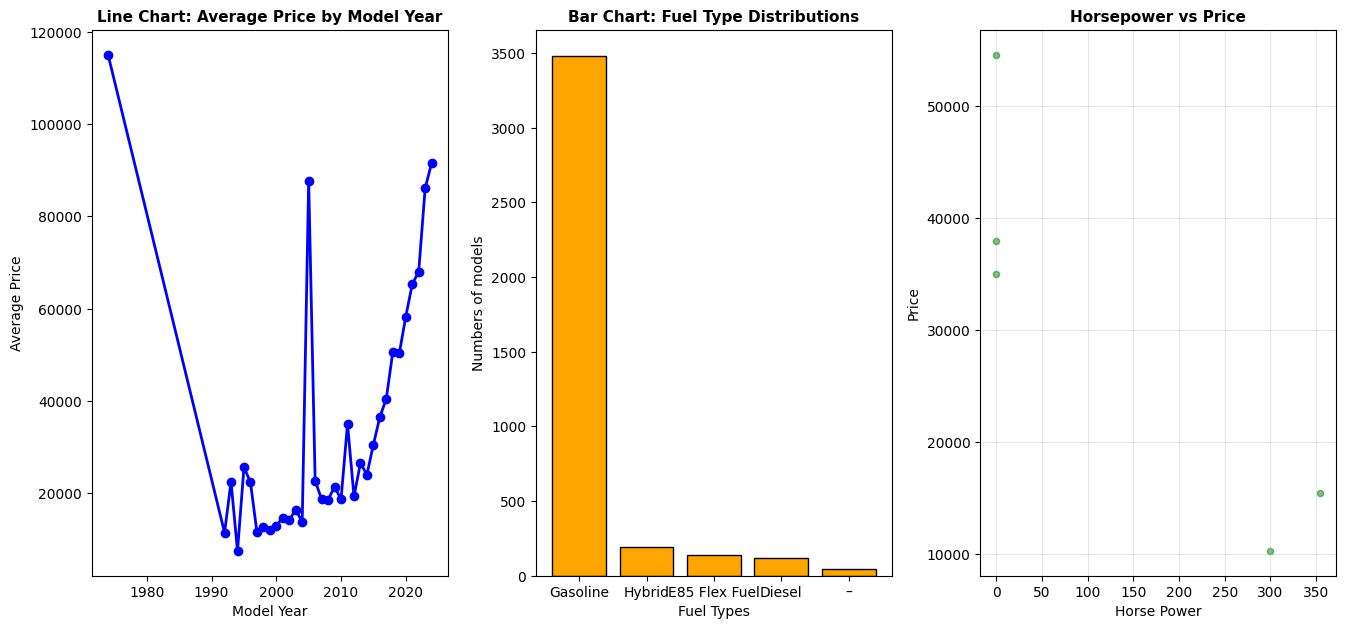

In [58]:
fig = plt.figure(figsize=(18,12))

ax1 = plt.subplot(2,4,1)
avg_price_by_year = clean_df.groupby('model_year')['price'].mean().sort_index()
ax1.plot(avg_price_by_year.index, avg_price_by_year.values, marker='o', linewidth=2, markersize=6, color='blue')
ax1.set_title('Line Chart: Average Price by Model Year', fontsize=11, fontweight='bold')
ax1.set_xlabel('Model Year')
ax1.set_ylabel('Average Price')

ax2 = plt.subplot(2,4,2)
fuel_counts = clean_df['fuel_type'].value_counts().head(5)
ax2.bar(fuel_counts.index, fuel_counts.values, color="orange", edgecolor='black')
ax2.set_title('Bar Chart: Fuel Type Distributions', fontsize=11, fontweight='bold')
ax2.set_xlabel('Fuel Types')
ax2.set_ylabel('Numbers of models')

ax3 = plt.subplot(2,4,3)
ax3.scatter(clean_df['horsepower'].head().dropna(), clean_df['price'].head().astype(float), alpha=0.5, s=20, color='green')
ax3.set_title("Horsepower vs Price", fontsize=11, fontweight='bold')
ax3.set_xlabel('Horse Power')
ax3.set_ylabel('Price')
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

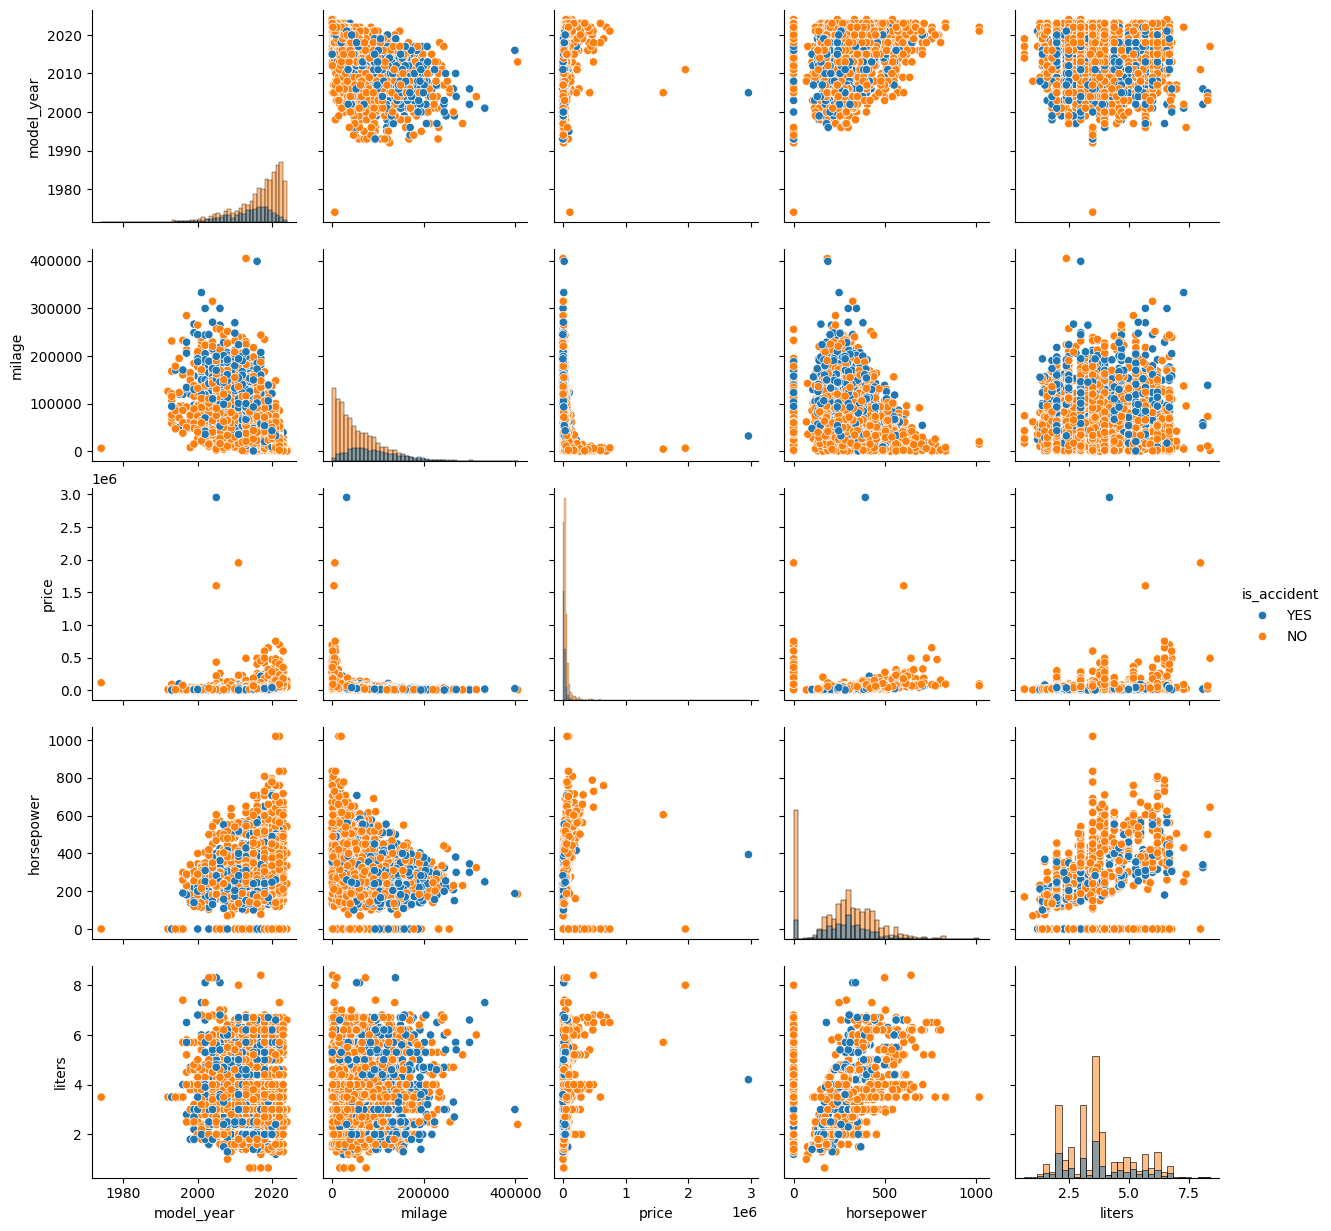

In [60]:
sns.pairplot(clean_df, diag_kind='hist', hue='is_accident')
plt.show()

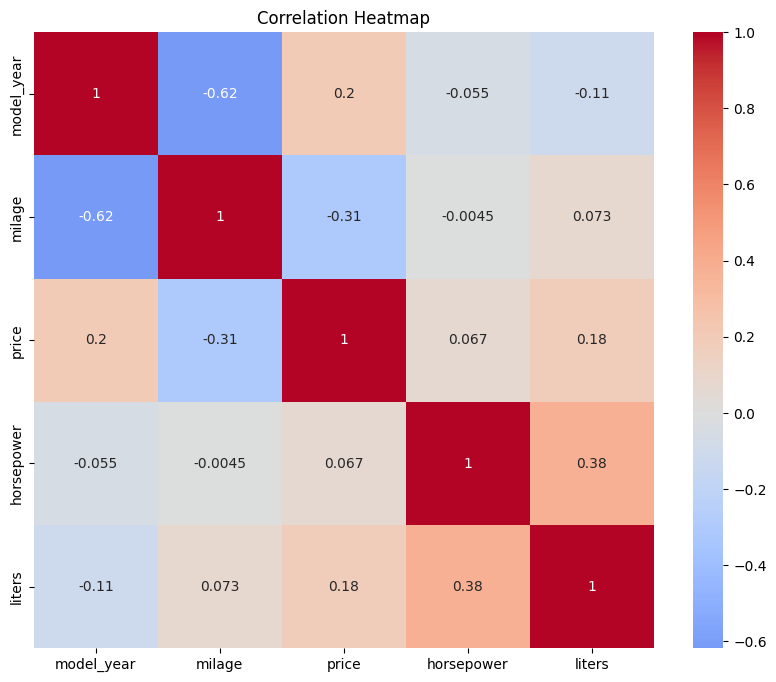

In [61]:
plt.figure(figsize=(10, 8))
numerical_df = clean_df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

### Identify and treat outliers

In [65]:
numerical_cols2 = clean_df.select_dtypes(include=np.number).columns.to_list()
numerical_cols2


['model_year', 'milage', 'price', 'horsepower', 'liters']

In [67]:
def iqr_outlier_detection(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return{
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier count': len(outliers),
        'Outlier percentage': (len(outliers) / len(df)) * 100
    }

outlier_summary = {}
for col in numerical_cols2:
    outlier_info = iqr_outlier_detection(clean_df, col)
    outlier_summary[col] = outlier_info

    print(f"\n{col}:")
    print(f"  Q1 (25th percentile): {outlier_info['Q1']:.2f}")
    print(f"  Q3 (75th percentile): {outlier_info['Q3']:.2f}")
    print(f"  IQR: {outlier_info['IQR']:.2f}")
    print(f"  Lower Bound: {outlier_info['Lower Bound']:.2f}")
    print(f"  Upper Bound: {outlier_info['Upper Bound']:.2f}")
    print(f"  Outliers Found: {outlier_info['Outlier count']} ({outlier_info['Outlier percentage']:.2f}%)")
    


model_year:
  Q1 (25th percentile): 2012.00
  Q3 (75th percentile): 2020.00
  IQR: 8.00
  Lower Bound: 2000.00
  Upper Bound: 2032.00
  Outliers Found: 67 (1.67%)

milage:
  Q1 (25th percentile): 23044.00
  Q3 (75th percentile): 94100.00
  IQR: 71056.00
  Lower Bound: -83540.00
  Upper Bound: 200684.00
  Outliers Found: 69 (1.72%)

price:
  Q1 (25th percentile): 17200.00
  Q3 (75th percentile): 49990.00
  IQR: 32790.00
  Lower Bound: -31985.00
  Upper Bound: 99175.00
  Outliers Found: 244 (6.09%)

horsepower:
  Q1 (25th percentile): 170.00
  Q3 (75th percentile): 381.00
  IQR: 211.00
  Lower Bound: -146.50
  Upper Bound: 697.50
  Outliers Found: 37 (0.92%)

liters:
  Q1 (25th percentile): 2.50
  Q3 (75th percentile): 4.60
  IQR: 2.10
  Lower Bound: -0.65
  Upper Bound: 7.75
  Outliers Found: 7 (0.17%)


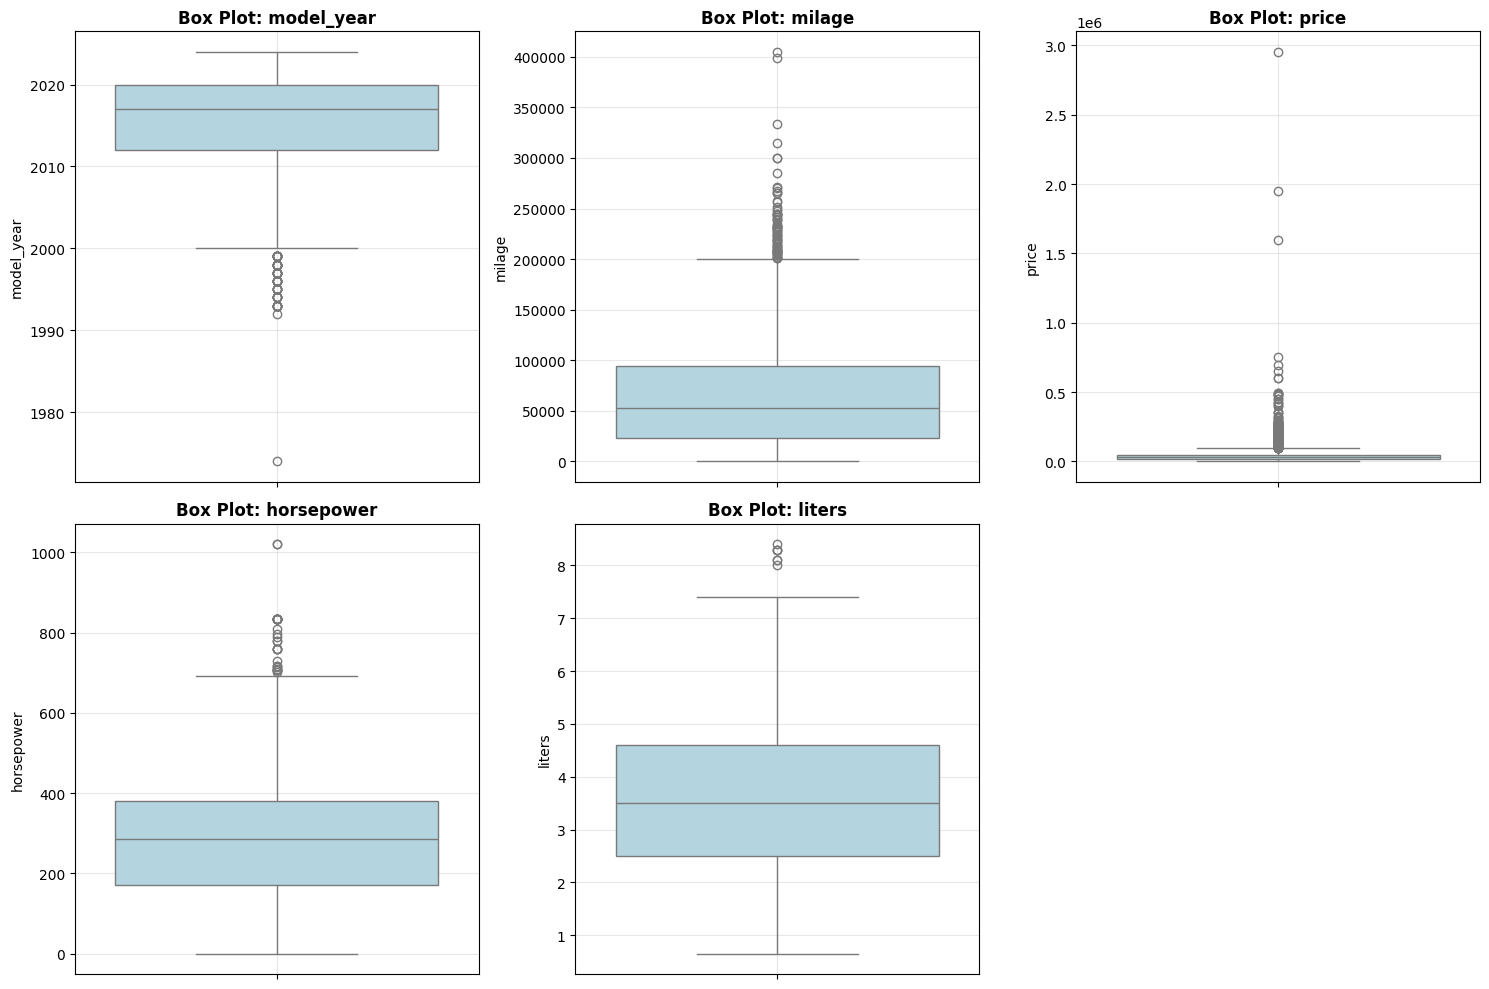

In [68]:
# Box plots for numerical columns to see outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols2):
    sns.boxplot(data=clean_df, y=col, ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'Box Plot: {col}', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(numerical_cols2), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [70]:
#capping the outliers
df_capped = clean_df.copy()
for col in numerical_cols2:
    lower_bound = outlier_summary[col]['Lower Bound']
    upper_bound = outlier_summary[col]['Upper Bound']
    
    # Cap the values
    df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)
    
    outliers_after = len(df_capped[(df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)])
    print(f"  {col}: Outliers after capping = {outliers_after}")



  model_year: Outliers after capping = 0
  milage: Outliers after capping = 0
  price: Outliers after capping = 0
  horsepower: Outliers after capping = 0
  liters: Outliers after capping = 0


In [71]:
clean_df.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,clean_title,price,horsepower,liters,is_accident
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,Yes,10300.0,300.0,3.7,YES
1,Hyundai,Palisade SEL,2021,34742,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,0.0,3.8,YES
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Automatic,Blue,Black,Yes,54598.0,0.0,3.5,NO
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,354.0,3.5,NO
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,Yes,34999.0,0.0,2.0,NO


### Implementing label encoding and ont-hot encoding

In [72]:
df_original = clean_df.copy()
clean_df = df_capped.copy()

In [73]:
print(f"Unique models: {clean_df['model'].nunique()}")

Unique models: 1898


In [74]:
clean_df = clean_df.drop('model', axis=1)

In [75]:
clean_df.head()

,brand,model_year,milage,fuel_type,transmission,ext_col,int_col,clean_title,price,horsepower,liters,is_accident
0,Ford,2013,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,Yes,10300.0,300.0,3.7,YES
1,Hyundai,2021,34742,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,0.0,3.8,YES
2,Lexus,2022,22372,Gasoline,Automatic,Blue,Black,Yes,54598.0,0.0,3.5,NO
3,INFINITI,2015,88900,Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,354.0,3.5,NO
4,Audi,2021,9835,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,Yes,34999.0,0.0,2.0,NO


In [76]:
print(f"Unique fuel_type: {clean_df['fuel_type'].nunique()}")
print(f"Unique brand: {clean_df['brand'].nunique()}")
print(f"Unique transmission: {clean_df['transmission'].nunique()}")
print(f"Unique external color: {clean_df['ext_col'].nunique()}")
print(f"Unique internal_color: {clean_df['int_col'].nunique()}")

Unique fuel_type: 6
Unique brand: 57
Unique transmission: 62
Unique external color: 319
Unique internal_color: 156


In [77]:
from sklearn.preprocessing import LabelEncoder

# one hot encoding for low cardinality
low_card = ['fuel_type', 'is_accident','clean_title']
clean_df = pd.get_dummies(clean_df, columns=low_card, drop_first=True)

# Label Encoding for high cardinality
high_card = ['brand', 'transmission', 'ext_col', 'int_col']
label_encoders = {}
for col in high_card:
    le = LabelEncoder()
    clean_df[col + '_encoded'] = le.fit_transform(clean_df[col])
    label_encoders[col] = le
    clean_df = clean_df.drop(col, axis=1)

print(clean_df.head())
print(f"Final shape: {clean_df.shape}")
print(f"Columns: {clean_df.columns.tolist()}")

   model_year  milage    price  horsepower  liters  fuel_type_E85 Flex Fuel  \
0        2013   51000  10300.0       300.0     3.7                     True   
1        2021   34742  38005.0         0.0     3.8                    False   
2        2022   22372  54598.0         0.0     3.5                    False   
3        2015   88900  15500.0       354.0     3.5                    False   
4        2021    9835  34999.0         0.0     2.0                    False   

   fuel_type_Gasoline  fuel_type_Hybrid  fuel_type_Plug-In Hybrid  \
0               False             False                     False   
1                True             False                     False   
2                True             False                     False   
3               False              True                     False   
4                True             False                     False   

   fuel_type_–  is_accident_YES  brand_encoded  transmission_encoded  \
0        False             True       

In [78]:
clean_df.head(2)

,model_year,milage,price,horsepower,liters,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,fuel_type_–,is_accident_YES,brand_encoded,transmission_encoded,ext_col_encoded,int_col_encoded
0,2013,51000,10300.0,300.0,3.7,True,False,False,False,False,True,14,16,29,14
1,2021,34742,38005.0,0.0,3.8,False,True,False,False,False,True,19,32,185,71


### Training  a logistic Regression model

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
clean_df['price_category'] = pd.cut(clean_df['price'], 
                                     bins=3, 
                                     labels=['LOW', 'MEDIUM', 'HIGH'])

X = clean_df.drop(['price', 'price_category'], axis=1) 
y = clean_df['price_category']

print(f"Price Distribution:")
print(y.value_counts())

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Price Distribution:
price_category
LOW       2192
MEDIUM    1225
HIGH       592
Name: count, dtype: int64


In [86]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [88]:
y_pred = log_reg.predict(X_test_scaled)

Accuracy: 0.7456

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.65      0.47      0.55       118
         LOW       0.86      0.88      0.87       453
      MEDIUM       0.56      0.63      0.59       231

    accuracy                           0.75       802
   macro avg       0.69      0.66      0.67       802
weighted avg       0.75      0.75      0.74       802



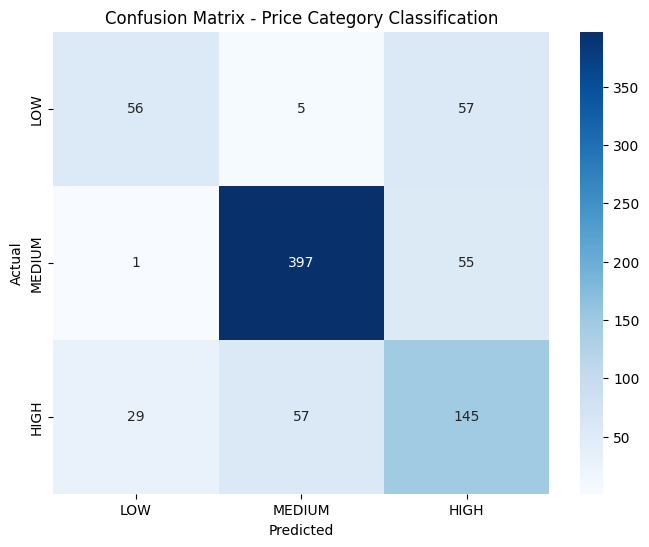

In [90]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['LOW', 'MEDIUM', 'HIGH'],
            yticklabels=['LOW', 'MEDIUM', 'HIGH'])
plt.title('Confusion Matrix - Price Category Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Linear regression

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#since we are predicting for price and it is continuous

In [94]:
X = clean_df.drop(['price', 'price_category'], axis=1) 
y_continuous = clean_df['price']


In [95]:
X_train, X_test, y_train_cont, y_test_cont = train_test_split(X, y_continuous, test_size=0.2, random_state=42)


In [96]:
scaler_lr = StandardScaler()  # Use different scaler name to avoid conflict
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

In [97]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_cont)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
y_pred_train = lin_reg.predict(X_train_scaled)
y_pred_test = lin_reg.predict(X_test_scaled)

In [ ]:
print(f"R2 Score (Train): {r2_score(y_train_cont, y_pred_train):.4f}")
print(f"R2 Score (Test): {r2_score(y_test_cont, y_pred_test):.4f}")
print(f"MAE (Test): ${mean_absolute_error(y_test_cont, y_pred_test):.2f}")
print(f"RMSE (Test): ${np.sqrt(mean_squared_error(y_test_cont, y_pred_test)):.2f}")


R² Score (Train): 0.6109
R² Score (Test): 0.6042
MAE (Test): $12617.25
RMSE (Test): $16373.43


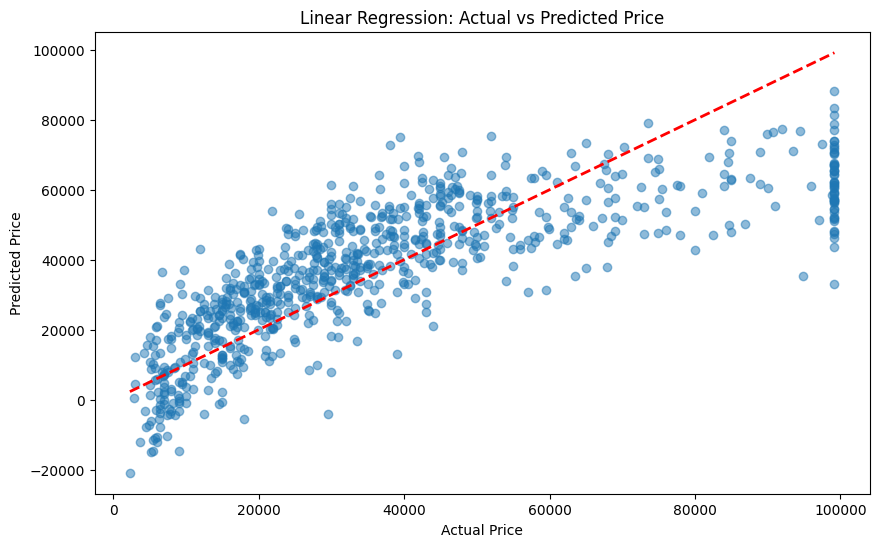

In [100]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_cont, y_pred_test, alpha=0.5)
plt.plot([y_test_cont.min(), y_test_cont.max()], [y_test_cont.min(), y_test_cont.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted Price')
plt.show()

In [101]:
import joblib

joblib.dump(lin_reg, 'models/linear_regression_model.pkl')

['models/linear_regression_model.pkl']

In [107]:
joblib.dump(log_reg, 'models/logistic_regression_model.pkl')


['models/logistic_regression_model.pkl']

### Implementing decision tree

In [108]:
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [109]:
X_tree = clean_df.drop(['price', 'price_category'], axis=1)
y_tree = clean_df['price']

In [110]:
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)

In [111]:
dt_default = DecisionTreeRegressor(random_state=42)
dt_default.fit(X_train_tree, y_train_tree)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [112]:
y_pred_train_default = dt_default.predict(X_train_tree)
y_pred_test_default = dt_default.predict(X_test_tree)

In [113]:
r2_train_default = r2_score(y_train_tree, y_pred_train_default)
r2_test_default = r2_score(y_test_tree, y_pred_test_default)
mae_default = mean_absolute_error(y_test_tree, y_pred_test_default)
rmse_default = np.sqrt(mean_squared_error(y_test_tree, y_pred_test_default))

In [ ]:
print(f"R2 Score (Train): {r2_train_default:.4f}")
print(f"R2 Score (Test): {r2_test_default:.4f}")
print(f"MAE (Test): ${mae_default:,.2f}")
print(f"RMSE (Test): ${rmse_default:,.2f}")
print(f"Tree Depth: {dt_default.get_depth()}")
print(f"Number of Leaves: {dt_default.get_n_leaves()}")

R² Score (Train): 1.0000
R² Score (Test): 0.6881
MAE (Test): $9,165.14
RMSE (Test): $14,533.79
Tree Depth: 24
Number of Leaves: 3001


In [115]:
joblib.dump(dt_default, 'models/decision_tree_model.pkl')

['models/decision_tree_model.pkl']

In [116]:
joblib.dump(scaler_lr, 'models/scaler_linear_regression.pkl')
joblib.dump(scaler, 'models/scaler_logistic_regression.pkl')

joblib.dump(label_encoders, 'models/label_encoders.pkl')


['models/label_encoders.pkl']